In [1274]:
import numpy as np
import pandas as pd
from scipy.stats import norm, binom, t

import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from arch import arch_model
warnings.filterwarnings("ignore")

# Data paths
DATA_RAW     = "data/data_real.xlsx"
DATA_PRICES  = "data/prices_clean.csv"
DATA_RETURNS = "data/returns_clean.csv"

# ── Time periods ──────────────────────────────────────────────────────────────
PRE_START    = "2015-01-01"
PRE_END      = "2016-12-31"
SAMPLE_START = "2017-01-01"
SAMPLE_END   = "2026-03-31"

# ── Portfolio ─────────────────────────────────────────────────────────────────
PORTFOLIO_VALUE = 1000000
LOAN_WEIGHT     = 0.20        # two-fund split: 20% bond, 80% tangency portfolio
RISKY_WEIGHT    = 0.80
WEIGHT_MIN      = 0.10
WEIGHT_MAX      = 0.30
LOAN_SPREAD_BPS = 150
TRADING_DAYS    = 252

# ── Asset lists ───────────────────────────────────────────────────────────────
STOCKS_USD = ["ASML", "SHELL", "JPM"]
INDEX_USD  = ["STOXX50", "SP500"]
RISKY_USD  = STOCKS_USD + INDEX_USD

STOCKS = ["ASML", "SHELL", "JPM_EUR"]
INDEX  = ["STOXX50", "SP500_EUR"]
RISKY  = STOCKS + INDEX

FX       = ["EURUSD"]
RATE     = ["EURIBOR3M"]
ALL_COLS = STOCKS_USD + INDEX_USD + FX + RATE   # ← only once, after FX/RATE defined

# NOTE: JPM_EUR and SP500_EUR in DATA_RETURNS are EUR-adjusted log-returns
#       (r_USD - r_EURUSD). Use RISKY for VaR/ES/portfolio P&L.
#       Use RISKY_USD vs RISKY for FX risk decomposition.


# ── Populated after running Section 4 — paste output back in ─────────────────
EURIBOR_T0    = -0.319000
LOAN_COUPON   = 0.011810
LOAN_MATURITY = 9.242984
LOAN_MOD_DUR  = 9.135099   # fixed-rate duration
WEIGHTS = {
    "ASML": 0.160000,
    "SHELL": 0.080000,
    "JPM_EUR": 0.240000,
    "STOXX50": 0.080000,
    "SP500_EUR": 0.240000,
    "LOAN": 0.200000,
}


assets = ['SHELL','ASML','JPM_EUR','STOXX50','SP500_EUR','LOAN']
ASSET_WEALTH = {asset : WEIGHTS[asset]*PORTFOLIO_VALUE for asset in assets}

In [1275]:
risky_returns = pd.read_csv("returns_clean.csv")

in_sample_returns = risky_returns[(risky_returns['Date']>=SAMPLE_START) ].copy()


ret_SHELL = in_sample_returns[['Date','SHELL']]
ret_ASML = in_sample_returns[['Date','ASML']]
ret_JPM = in_sample_returns[['Date','JPM_EUR']]
ret_STOXX50 = in_sample_returns[['Date','STOXX50']]
ret_SP500 = in_sample_returns[['Date','SP500_EUR']]
ret_LOAN = in_sample_returns[['Date','LOAN']]


In [1276]:
in_sample_returns.head()

,Date,ASML,SHELL,JPM,STOXX50,SP500,EURUSD,EURIBOR3M,JPM_EUR,SP500_EUR,LOAN
512,2017-01-02,0.003744,0.009003,0.000000,0.000000,0.000000,-0.004579,0.001,0.004579,0.004579,-0.000044
513,2017-01-03,-0.004213,0.011942,0.010834,0.007418,0.008451,-0.006380,-0.001,0.017214,0.014831,0.000138
514,2017-01-04,-0.013695,0.004887,0.001843,0.000754,0.005706,-0.003842,-0.001,0.005685,0.009548,0.000138
515,2017-01-05,0.002375,-0.005075,-0.009248,-0.000317,-0.000771,0.007741,-0.001,-0.016988,-0.008512,0.000138
516,2017-01-06,0.000000,-0.003966,0.000116,0.001416,0.003511,0.009952,0.000,-0.009836,-0.006441,0.000047


In [1277]:
mu_SHELL = ret_SHELL['SHELL'].mean()
mu_ASML = ret_ASML['ASML'].mean()
mu_JPM_EUR = ret_JPM['JPM_EUR'].mean()
mu_STOXX50 = ret_STOXX50['STOXX50'].mean()
mu_SP500_EUR = ret_SP500['SP500_EUR'].mean()
mu_LOAN = ret_LOAN['LOAN'].mean()

mu = {
    'ASML': mu_ASML,
    'SHELL': mu_SHELL,
    'JPM_EUR': mu_JPM_EUR,
    'STOXX50': mu_STOXX50,
    'SP500_EUR': mu_SP500_EUR,
    'LOAN': mu_LOAN
}

# Innovation calculation

In [1278]:

innovations = {}

for asset in assets:

    innovations[asset] = in_sample_returns[['Date', asset]].copy()
    innovations[asset][asset] = innovations[asset][asset] - innovations[asset][asset].mean()



# CCC GARCH(1,1) fitting: for each element


In [1279]:
volatility_process = {}
forecasted_vol_process = {}


for asset in assets:
    innovation_series = innovations[asset][asset]

    model = arch_model(innovation_series, vol='Garch', p=1, q=1, mean='Zero')
    res = model.fit(disp='off')

    volatility_process[asset] = pd.DataFrame({
        'Date': innovations[asset]['Date'],
        'Volatility': res.conditional_volatility
    })

    params = res.params
    omega = params[0]
    alpha = params[1]
    beta = params[2]


    sigma_last = res.conditional_volatility.iloc[-1]
    forecasted_vol_process[asset] = []


    a = innovations[asset].iloc[-1][asset]
    sigma_next = np.sqrt(omega + alpha * a**2 + beta * sigma_last**2)
    forecasted_vol_process[asset].append(sigma_next)


    forecasted_vol_process[asset] = pd.DataFrame({
    'Date': 'Next Day',
    'Volatility': forecasted_vol_process[asset]
    })

C:\Users\hp\miniconda3\Lib\site-packages\arch\univariate\base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(


In [1280]:

dates = volatility_process['SHELL']['Date'].copy()
n_obs = len(dates)

n_assets = len(assets)
n_obs_out = 1
Delta = np.zeros((n_obs, n_assets, n_assets))
Delta_hat_next = np.zeros((n_obs_out, n_assets, n_assets))

for i, asset in enumerate(assets):
    Delta[:, i, i] = pd.array(volatility_process[asset]['Volatility'].values)
    Delta_hat_next[:, i, i] = pd.array(forecasted_vol_process[asset]['Volatility'].values)




In [1281]:
Devol_innovations = {}
for asset in assets:

    Devol_innovations[asset] = innovations[asset].copy()
    Devol_innovations[asset][asset] = innovations[asset][asset]/volatility_process[asset]['Volatility'].values


In [1282]:
Y = pd.DataFrame({
    asset: Devol_innovations[asset][asset].values
    for asset in assets
})

P = Y.corr()



In [1283]:
Sigmas = np.zeros((n_obs, n_assets, n_assets))
for i in range(len(dates)):
    Sigmas[i] = Delta[i]@P@Delta[i]

In [1284]:
Sigmas_predicted = np.zeros((n_obs_out, n_assets, n_assets))

Sigmas_predicted[0] = Delta_hat_next[0]@P@Delta_hat_next[0]

In [1285]:
Sigmas_dict = {
    dates.iloc[t]: Sigmas[t]
    for t in range(len(dates))
}

# Conditional 95% 1-day VAR and ES for the elements and for portfolio

In [1286]:
alpha = 0.99
z = norm.ppf(alpha)
print(z)
phi_z = norm.pdf(z)
VAR_95_predicted = {}
ES_95_predicted = {}


for i, asset in enumerate(assets):
    sigma_hat_it = np.sqrt(Sigmas_predicted[0][i, i])
    VAR_95_predicted[asset] = ASSET_WEALTH[asset]*(-mu[asset] + z * sigma_hat_it)
    ES_95_predicted[asset] = ASSET_WEALTH[asset]*(mu[asset] + sigma_hat_it * phi_z / (1 - alpha))



2.3263478740408408


In [1287]:
VAR_95_predicted

{'SHELL': 2888.282519579268,
 'ASML': 8804.489674661065,
 'JPM_EUR': 7993.55312257627,
 'STOXX50': 2102.2617906255814,
 'SP500_EUR': 6425.145160203531,
 'LOAN': 942.8663454593757}

In [1288]:
ES_95_predicted

{'SHELL': 3377.0540265484583,
 'ASML': 10440.21195271759,
 'JPM_EUR': 9452.463803269418,
 'STOXX50': 2446.3049944522227,
 'SP500_EUR': 7569.652303192333,
 'LOAN': 1059.8754942405653}

# Conditional historical 95% 1-day VAR and ES for the elements

In [1289]:

VAR_95 = pd.DataFrame(index=Sigmas_dict.keys(), columns=assets)

for date, Sigma_hat_t in Sigmas_dict.items():
    for i, asset in enumerate(assets):
        sigma_hat_it = np.sqrt(Sigma_hat_t[i, i])  # volatility
        VAR_95.loc[date, asset] = ASSET_WEALTH[asset]*(-mu[asset] + z * sigma_hat_it)



In [1290]:

phi_z = norm.pdf(z)
ES_95 = pd.DataFrame(index=Sigmas_dict.keys(), columns=assets)

for date, Sigma_hat_t in Sigmas_dict.items():
    for i, asset in enumerate(assets):
        sigma_hat_it = np.sqrt(Sigma_hat_t[i, i])
        ES_95.loc[date, asset] = (mu[asset] + sigma_hat_it * phi_z / (1 - alpha))*ASSET_WEALTH[asset]




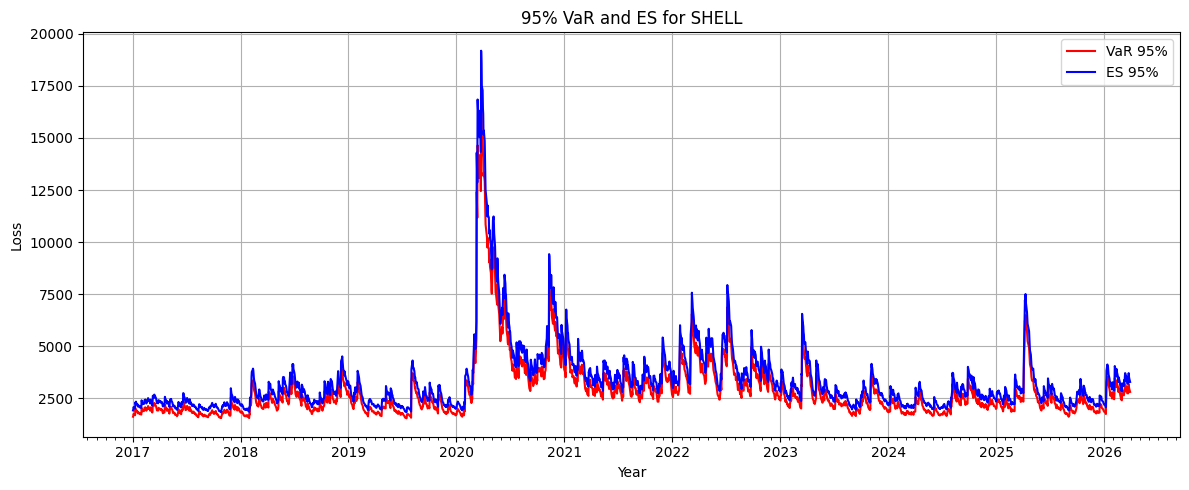

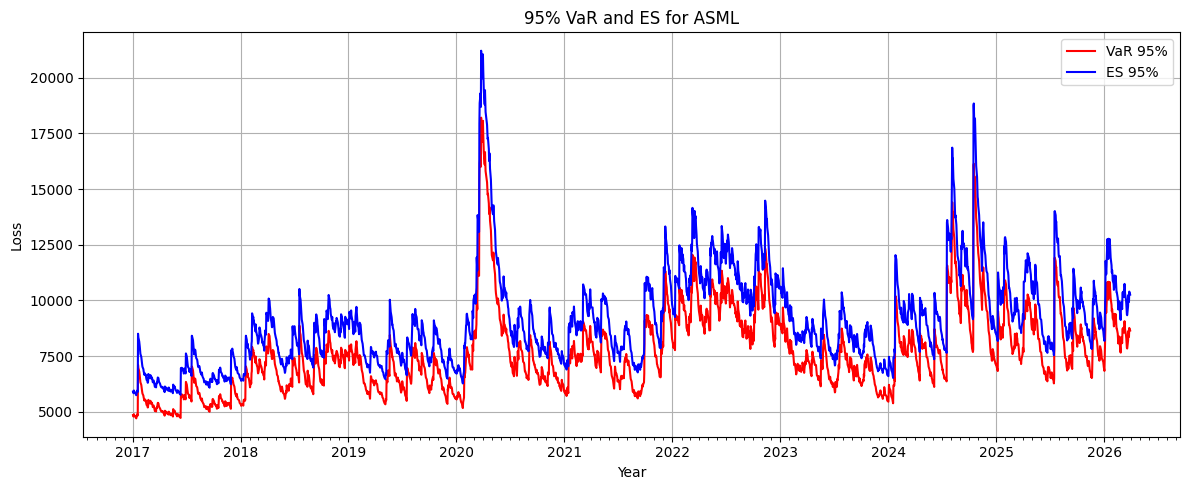

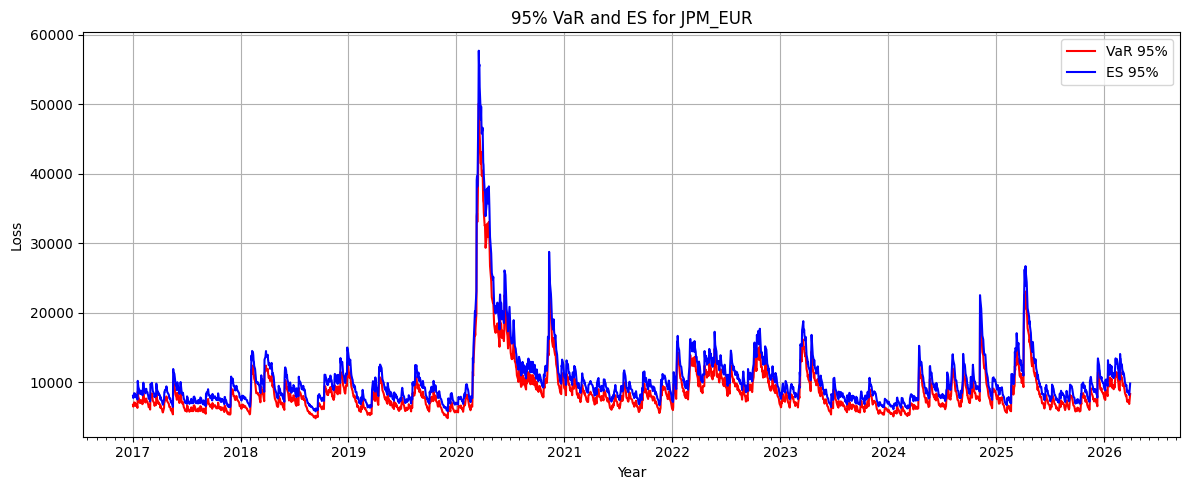

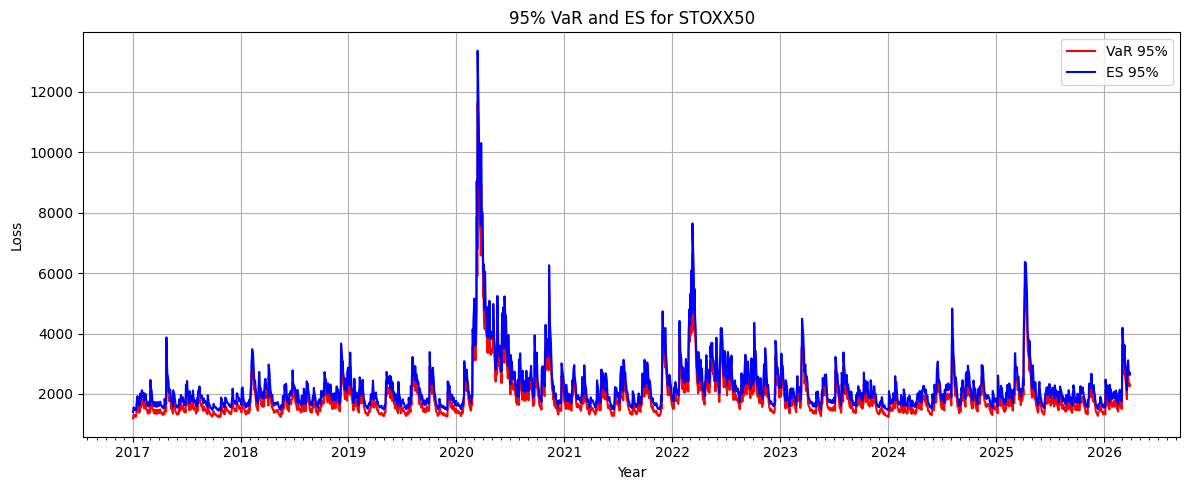

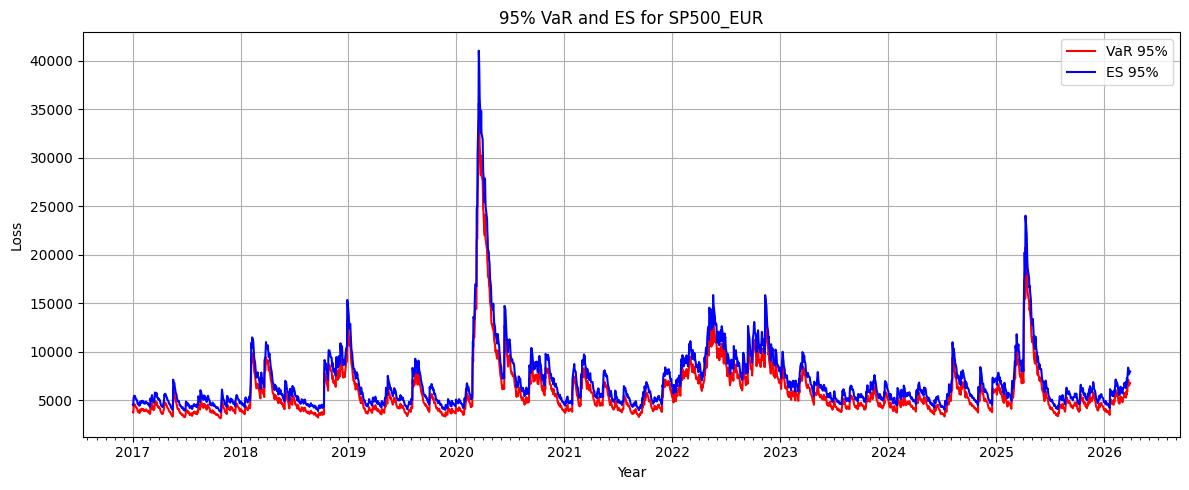

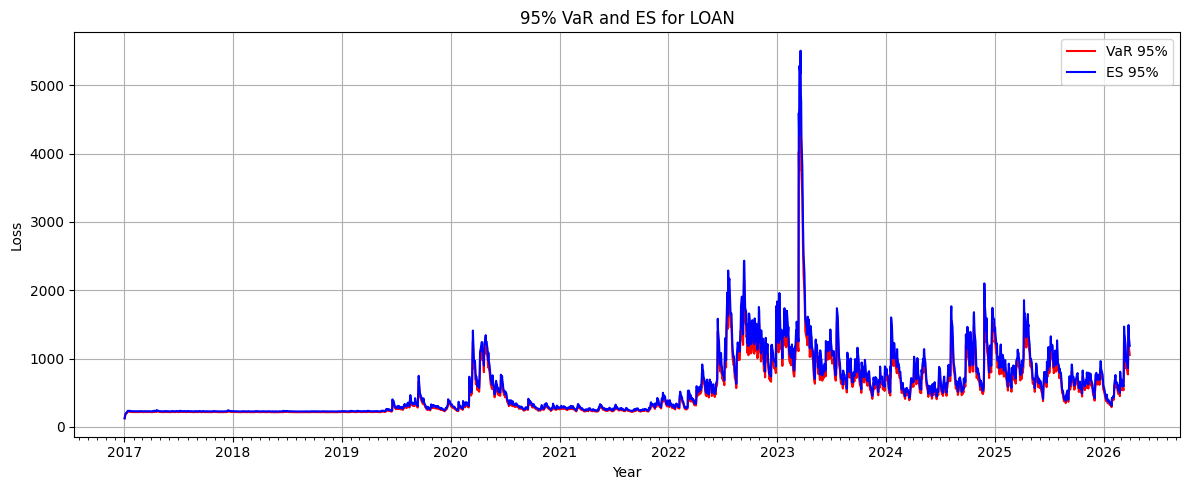

In [1291]:
VAR_95.index = pd.to_datetime(VAR_95
.index)
ES_95.index = pd.to_datetime(ES_95
.index)

for asset in assets:
    plt.figure(figsize=(12,5))
    plt.plot(VAR_95
.index, VAR_95
[asset], label='VaR 95%', color='red')
    plt.plot(ES_95
.index, ES_95
[asset], label='ES 95%', color='blue')
    plt.title(f'95% VaR and ES for {asset}')
    plt.xlabel('Year')
    plt.ylabel('Loss')

    ax = plt.gca()


    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Conditional  95% 1-day Var and ES for Portfolio

In [1292]:
Portfolio_return = pd.DataFrame(index=risky_returns['Date'],columns=['Port_return'])
for time in Portfolio_return.index:
    Portfolio_return.loc[time,'Port_return'] = 0
    for asset in assets:
        Portfolio_return.loc[time,'Port_return'] += WEIGHTS[asset]* risky_returns.loc[risky_returns['Date'] == time, asset].values[0]

In [1293]:
Portfolio_return = PORTFOLIO_VALUE*Portfolio_return[Portfolio_return.index>= SAMPLE_START]

In [1294]:
Portfolio_mu = 0
Portfolio_sigma = pd.DataFrame(index=Sigmas_dict.keys(), dtype=float,columns= ['Port_Volatility'])
w = np.array([WEIGHTS[asset] for asset in assets])
for asset in assets:
    Portfolio_mu+= WEIGHTS[asset]*mu[asset]
for date, Sigma_t in Sigmas_dict.items():
    port_var_hat = w.T @ Sigma_t @ w
    Portfolio_sigma.loc[date, 'Port_Volatility'] = np.sqrt(port_var_hat)
Portfolio_sigma = Portfolio_sigma.sort_index()
Portfolio_mu


0.0004389698446587715

In [1295]:
Portfolio_VaR_95 = PORTFOLIO_VALUE*(-Portfolio_mu + z * Portfolio_sigma['Port_Volatility'])
Portfolio_ES_95 = PORTFOLIO_VALUE*(Portfolio_mu + Portfolio_sigma['Port_Volatility'] * phi_z / (1 - alpha))


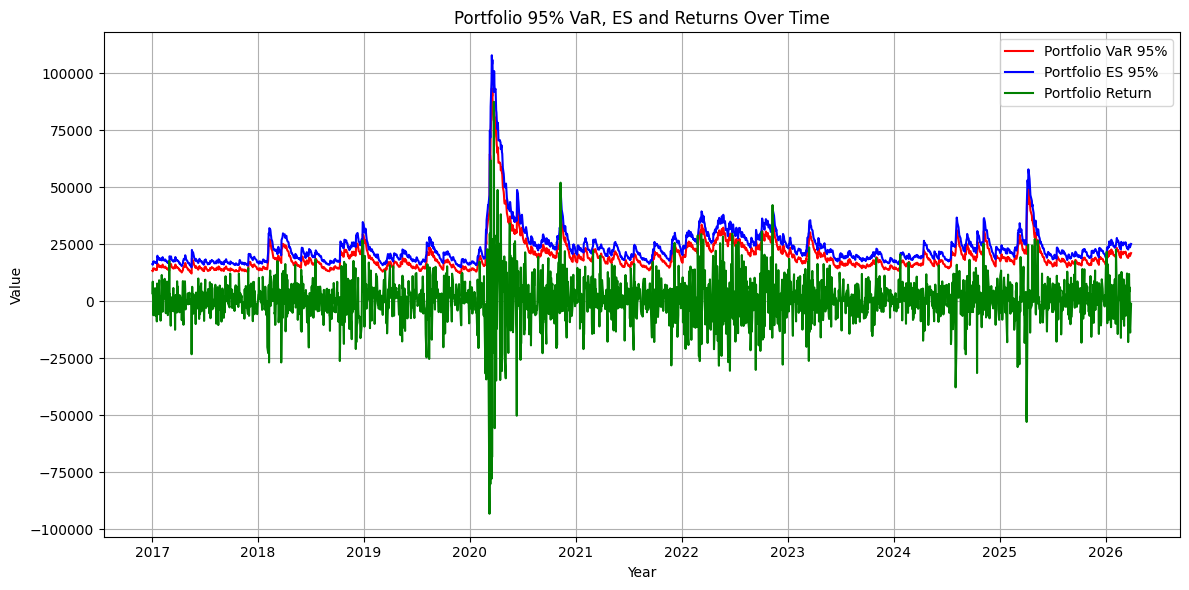

In [1296]:
Portfolio_sigma.index = pd.to_datetime(Portfolio_sigma.index)
Portfolio_VaR_95.index = pd.to_datetime(Portfolio_VaR_95.index)
Portfolio_ES_95.index = pd.to_datetime(Portfolio_ES_95.index)

plt.figure(figsize=(12,6))

plt.plot(Portfolio_VaR_95.index, Portfolio_VaR_95.values, label='Portfolio VaR 95%', color='red')
plt.plot(Portfolio_ES_95.index, Portfolio_ES_95.values, label='Portfolio ES 95%', color='blue')
plt.plot(Portfolio_ES_95.index, Portfolio_return.values, label='Portfolio Return', color='green')

plt.title('Portfolio 95% VaR, ES and Returns Over Time')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(True)
plt.tight_layout()
plt.show()

# Back testing


In [1297]:
Losses= {}
for asset in assets:
    Losses[asset] = in_sample_returns[['Date',asset]]
    Losses[asset][asset] = -ASSET_WEALTH[asset]*in_sample_returns[['Date',asset]][asset]

In [1298]:
Losses_Port = -Portfolio_return
Losses_Port.columns = ['Port_loss']
Losses_Port.index = pd.to_datetime(Losses_Port.index)


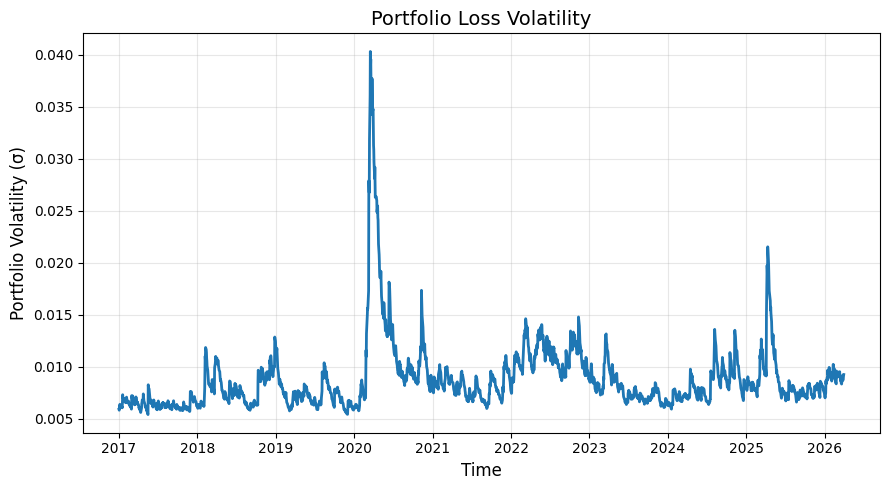

In [1315]:

plt.figure(figsize=(9, 5))

plt.plot(
    Portfolio_sigma['Port_Volatility'],
    linewidth=2
)

plt.title("Portfolio Loss Volatility", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Portfolio Volatility (σ)", fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

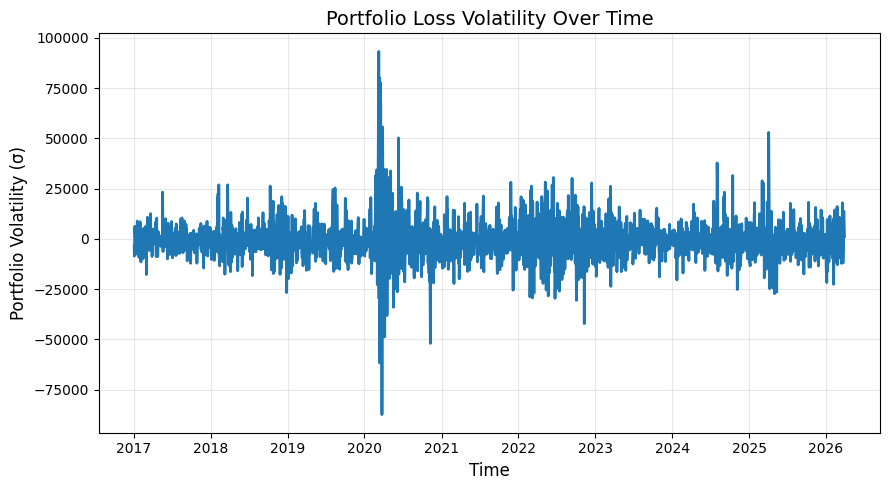

In [1313]:

plt.figure(figsize=(9, 5))

plt.plot(
    Losses_Port,
    linewidth=2
)

plt.title("Portfolio Loss Volatility Over Time", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Portfolio Volatility (σ)", fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# Portfolio VaR violations and average ES (2025)


In [1306]:


years = list(range(2017, 2027))

alpha_c = 0.05


for i in range(len(years)):

    start = f"{years[i]}-01-01"
    end = f"{years[i] + 1}-01-01" if years[i] < 2026 else "2026-03-30"

    mask = (Losses_Port.index >= start) & (Losses_Port.index <= end)

    loss_series = Losses_Port.loc[mask, 'Port_loss']
    var_series = Portfolio_VaR_95.loc[mask]
    es_series = Portfolio_ES_95.loc[mask]

    loss_series, var_series = loss_series.align(var_series, join='inner')
    loss_series, es_series = loss_series.align(es_series, join='inner')

    violations = loss_series > var_series
    Ic_hat = violations.sum()
    T = len(violations)

    p = 1 - alpha
    expected = T * p

    cL = binom.ppf(alpha_c / 2, T, p)
    cU = binom.ppf(1 - alpha_c / 2, T, p)

    reject_VaR = (Ic_hat < cL) or (Ic_hat > cU)


    if Ic_hat > 0:

        denom = es_series - var_series

        residual = (loss_series - es_series) / denom
        residual = residual[violations]

        residual = residual.replace([np.inf, -np.inf], np.nan).dropna()
        n_t= len(residual)
        K_hat = residual.mean()
        S_k = residual.std()
        df = Ic_hat

        t_lower = t.ppf(alpha_c/2, df)
        t_upper = t.ppf(1 - alpha_c/2, df)

        if len(residual) >= 1:
            t_stat = n_t*K_hat / S_k
            reject_ES = (t_stat < t_lower) or (t_stat > t_upper)
        else:
            t_stat= np.nan
            reject_ES = False

        avg_shortfall = (loss_series[violations]).mean()

    else:
        residual = pd.Series(dtype=float)
        t_stat, p_value = np.nan, np.nan
        reject_ES = False
        avg_shortfall = 0.0

    ES_avg = es_series.mean()


    print(
        f"\nPortfolio ({start} to {end}):\n"
        f"VaR violations = {Ic_hat} / {T} (expected ~{expected:.1f})\n"
        f"VaR critical region: [{cL:.0f}, {cU:.0f}]\n"
        f"Reject VaR H0: {reject_VaR}\n\n"
        f"ES t-test:\n"
        f"t-stat = {t_stat:.4f},CI =  [{t_lower:.4f},{t_upper:.4f}]\n"
        f"Reject ES H0: {reject_ES}\n"
        f"Average shortfall = {avg_shortfall:.4f}\n"
        f"Average ES = {ES_avg:.4f}\n"
    )


Portfolio (2017-01-01 to 2018-01-01):
VaR violations = 1 / 256 (expected ~2.6)
VaR critical region: [0, 6]
Reject VaR H0: False

ES t-test:
t-stat = nan,CI =  [-12.7062,12.7062]
Reject ES H0: False
Average shortfall = 23247.4330
Average ES = 17509.3869


Portfolio (2018-01-01 to 2019-01-01):
VaR violations = 7 / 255 (expected ~2.6)
VaR critical region: [0, 6]
Reject VaR H0: True

ES t-test:
t-stat = 3.6242,CI =  [-2.3646,2.3646]
Reject ES H0: True
Average shortfall = 23432.1580
Average ES = 21738.0819


Portfolio (2019-01-01 to 2020-01-01):
VaR violations = 4 / 255 (expected ~2.6)
VaR critical region: [0, 6]
Reject VaR H0: False

ES t-test:
t-stat = 2.2088,CI =  [-2.7764,2.7764]
Reject ES H0: False
Average shortfall = 21938.3965
Average ES = 19805.1167


Portfolio (2020-01-01 to 2021-01-01):
VaR violations = 10 / 257 (expected ~2.6)
VaR critical region: [0, 6]
Reject VaR H0: True

ES t-test:
t-stat = 5.0209,CI =  [-2.2281,2.2281]
Reject ES H0: True
Average shortfall = 39274.4522
Avera

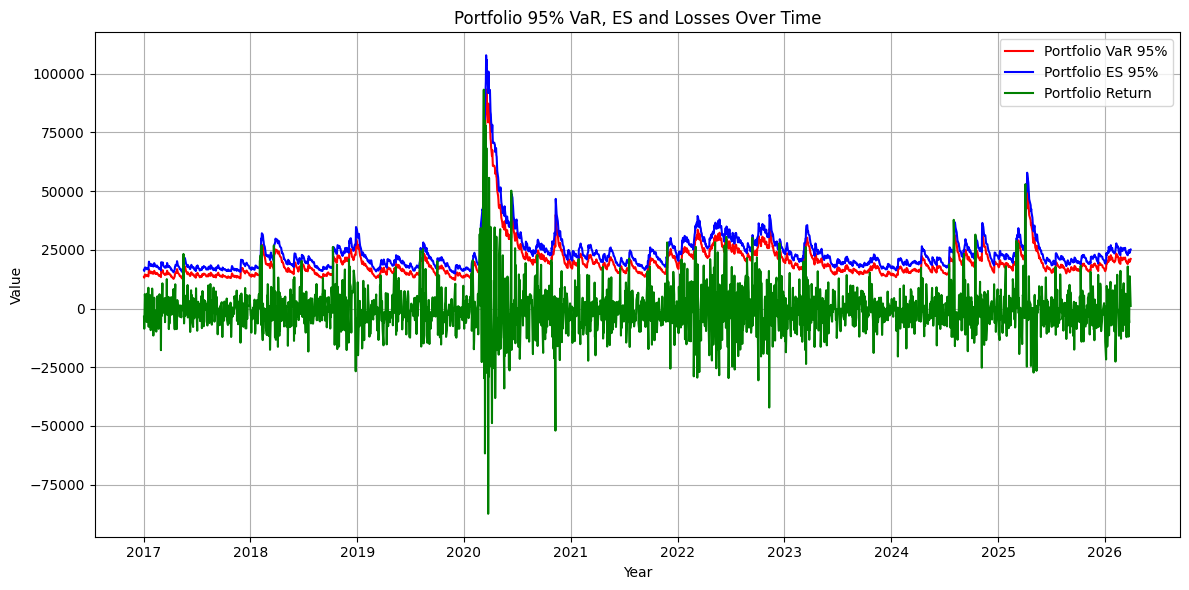

In [1300]:
Portfolio_sigma.index = pd.to_datetime(Portfolio_sigma.index)
Portfolio_VaR_95.index = pd.to_datetime(Portfolio_VaR_95.index)
Portfolio_ES_95.index = pd.to_datetime(Portfolio_ES_95.index)

plt.figure(figsize=(12,6))

plt.plot(Portfolio_VaR_95.index, Portfolio_VaR_95.values, label='Portfolio VaR 95%', color='red')
plt.plot(Portfolio_ES_95.index, Portfolio_ES_95.values, label='Portfolio ES 95%', color='blue')
plt.plot(Portfolio_ES_95.index, Losses_Port.values, label='Portfolio Return', color='green')

plt.title('Portfolio 95% VaR, ES and Losses Over Time')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(True)
plt.tight_layout()
plt.show()

In [1301]:
Portfolio_sigma_hat = np.sqrt(w.T @ Sigmas_predicted[0] @ w)

In [1302]:
VAR_95_predicted_port = PORTFOLIO_VALUE*(-Portfolio_mu+Portfolio_sigma_hat*z)
ES_95_predicted_port = PORTFOLIO_VALUE*(Portfolio_mu+Portfolio_sigma_hat*phi_z/(1-alpha) )

In [1303]:
VAR_95_predicted['Portfolio'] = VAR_95_predicted_port
ES_95_predicted['Portfolio'] = ES_95_predicted_port
ES_95_predicted

{'SHELL': 3377.0540265484583,
 'ASML': 10440.21195271759,
 'JPM_EUR': 9452.463803269418,
 'STOXX50': 2446.3049944522227,
 'SP500_EUR': 7569.652303192333,
 'LOAN': 1059.8754942405653,
 'Portfolio': 24522.71875042075}

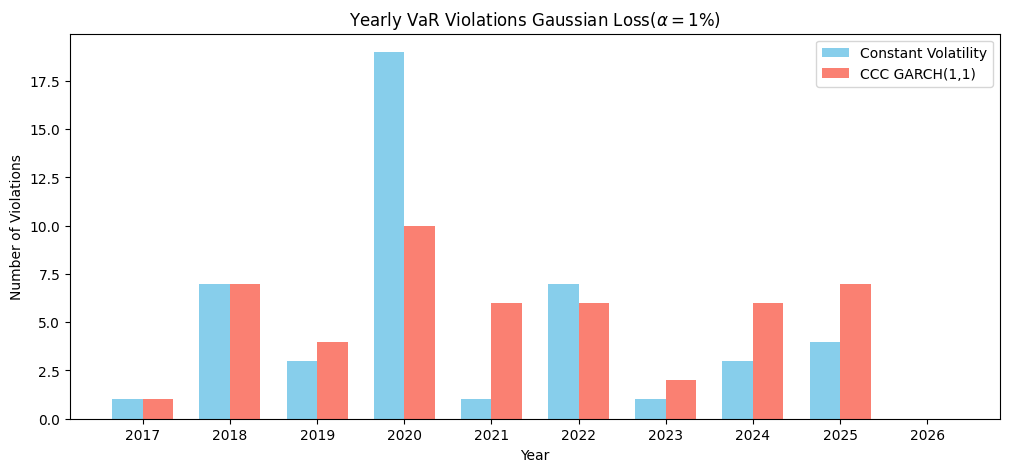

In [1304]:


years = np.array([2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026])
violations_const = np.array([1, 7, 3, 19, 1, 7, 1, 3, 4, 0])  # constant volatility
violations_garch = np.array([1, 7, 4, 10, 6, 6, 2, 6, 7, 0])  # CCC-GARCH(1,1)
width = 0.35
plt.figure(figsize=(12,5))
plt.bar(years - width/2, violations_const, width=width, color='skyblue', label='Constant Volatility')
plt.bar(years + width/2, violations_garch, width=width, color='salmon', label='CCC GARCH(1,1)')
plt.title("Yearly VaR Violations Gaussian Loss($\\alpha = 1\\%$)")
plt.xlabel("Year")
plt.ylabel("Number of Violations")
plt.xticks(years)
plt.legend()
plt.show()